# Notebook 06 — Fairness Analysis & Project Summary

Checks model fairness across age and income groups, applies the
80 % rule, and prints the final project summary.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from src.preprocessing import load_preprocessed
from src.model_utils import load_model

In [2]:
X_train, X_test, y_train, y_test, scaler = load_preprocessed('../outputs')
X_orig = pd.read_csv('../outputs/X_original.csv')
y_orig = pd.read_csv('../outputs/y_original.csv')['loan_approved']
best_model = load_model('best_model', model_dir='../models')
y_pred = best_model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}  F1: {f1_score(y_test, y_pred):.4f}')

Loaded  X_train=(17534, 14)  X_test=(2474, 14)
Loaded ../models/best_model.pkl
Accuracy: 1.0000  F1: 1.0000


In [3]:
# Reconstruct original test split to get real ages & incomes
_, X_test_orig, _, _ = train_test_split(X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig)
ages = X_test_orig['age'].values
incomes = X_test_orig['income'].values
age_bins = pd.cut(ages, bins=[0, 30, 45, 60, 100], labels=['18-30','31-45','46-60','60+'])

In [4]:
# Age-group fairness
print('FAIRNESS — AGE GROUPS')
print('='*80)
fair = []
for g in ['18-30','31-45','46-60','60+']:
    m = age_bins == g
    if m.sum() == 0: continue
    yt = y_test.values[m]; yp = y_pred[m]
    cm = confusion_matrix(yt, yp, labels=[0,1])
    tn,fp,fn,tp = cm.ravel() if cm.size==4 else (0,0,0,0)
    tpr = tp/(tp+fn) if tp+fn else 0
    fpr = fp/(fp+tn) if fp+tn else 0
    fair.append({'Age': g, 'N': m.sum(), 'Approval%': round(yp.mean()*100,2), 'Acc': round(accuracy_score(yt,yp),4), 'TPR': round(tpr,4), 'FPR': round(fpr,4)})
fdf = pd.DataFrame(fair)
print(fdf.to_string(index=False))

FAIRNESS — AGE GROUPS
  Age   N  Approval%  Acc  TPR  FPR
18-30 550      11.27  1.0  1.0  0.0
31-45 881      11.58  1.0  1.0  0.0
46-60 780      10.51  1.0  1.0  0.0
  60+ 263      13.31  1.0  1.0  0.0


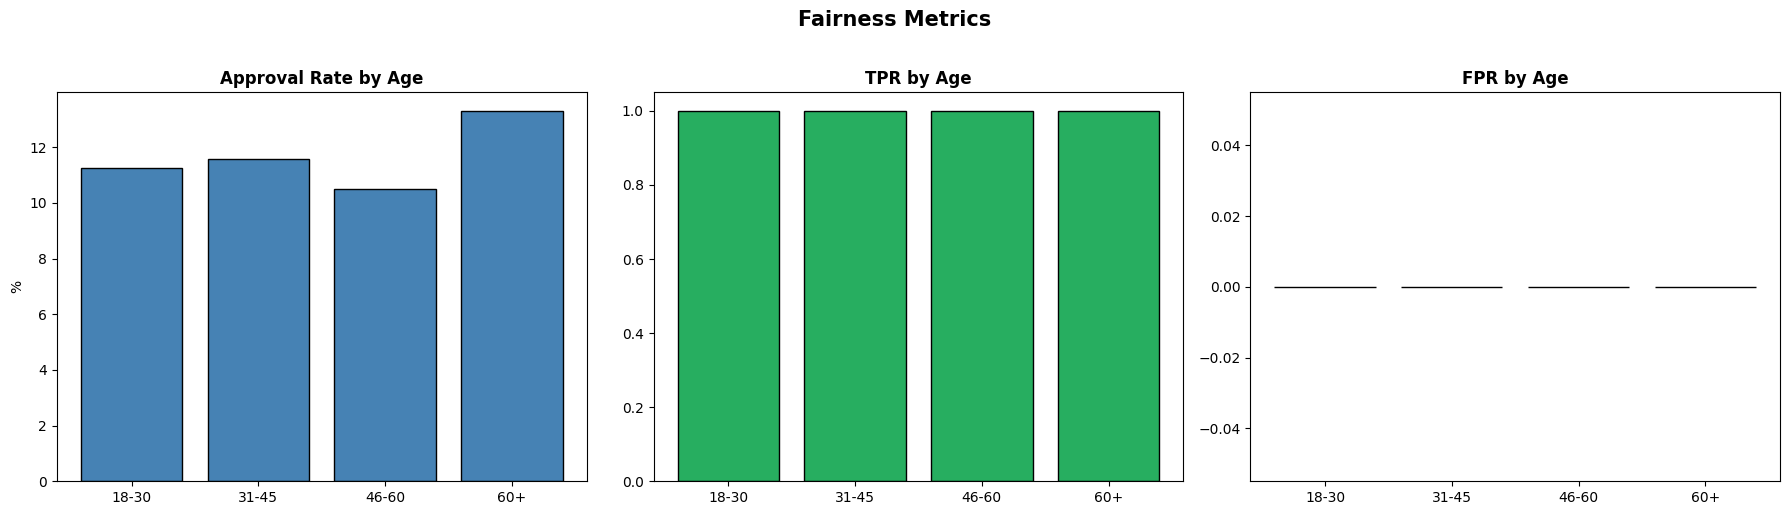

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(fdf['Age'], fdf['Approval%'], color='steelblue', edgecolor='black')
axes[0].set_title('Approval Rate by Age', fontweight='bold'); axes[0].set_ylabel('%')
axes[1].bar(fdf['Age'], fdf['TPR'], color='#27ae60', edgecolor='black')
axes[1].set_title('TPR by Age', fontweight='bold')
axes[2].bar(fdf['Age'], fdf['FPR'], color='#e74c3c', edgecolor='black')
axes[2].set_title('FPR by Age', fontweight='bold')
plt.suptitle('Fairness Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('../outputs/fairness_age.png', dpi=150, bbox_inches='tight'); plt.show()


FAIRNESS — INCOME GROUPS
   Income   N  Approval%  Acc
      Low 569      11.25  1.0
   Medium 595      11.60  1.0
     High 700      13.43  1.0
Very High 610       8.85  1.0


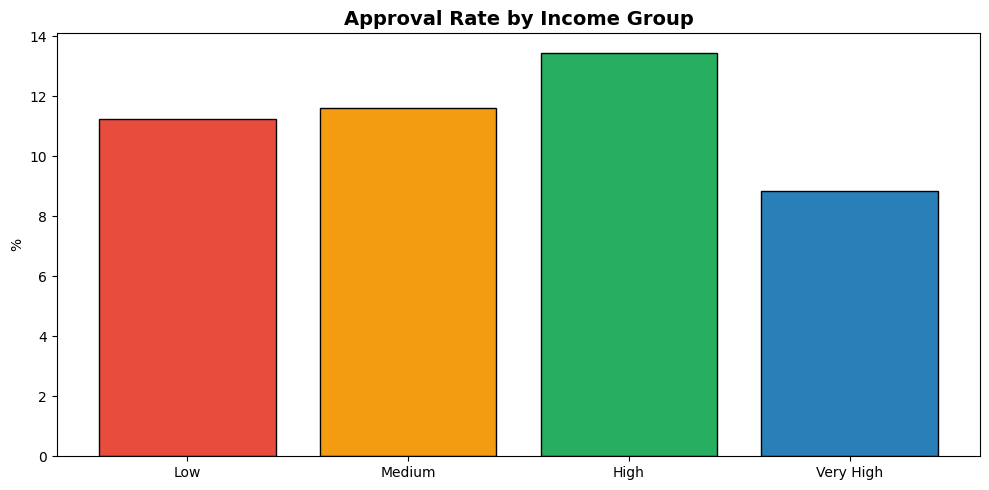

In [6]:
# Income group fairness
inc_bins = pd.cut(incomes, bins=4, labels=['Low','Medium','High','Very High'])
print('\nFAIRNESS — INCOME GROUPS')
print('='*80)
inc_fair = []
for g in ['Low','Medium','High','Very High']:
    m = inc_bins == g
    if m.sum() == 0: continue
    yt = y_test.values[m]; yp = y_pred[m]
    inc_fair.append({'Income': g, 'N': m.sum(), 'Approval%': round(yp.mean()*100,2),
                     'Acc': round(accuracy_score(yt,yp),4)})
idf = pd.DataFrame(inc_fair)
print(idf.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(idf['Income'], idf['Approval%'], color=['#e74c3c','#f39c12','#27ae60','#2980b9'], edgecolor='black')
plt.title('Approval Rate by Income Group', fontweight='bold', fontsize=14); plt.ylabel('%')
plt.tight_layout(); plt.savefig('../outputs/fairness_income.png', dpi=150, bbox_inches='tight'); plt.show()

In [7]:
# 80% rule
print('\n80% RULE (Disparate Impact)\n' + '='*60)
mx = fdf['Approval%'].max()
for _, r in fdf.iterrows():
    ratio = r['Approval%'] / mx if mx else 0
    ok = 'PASS' if ratio >= 0.80 else 'FAIL'
    print(f"  {r['Age']:<10}: {r['Approval%']:>7.2f}%  ratio={ratio:.3f}  {ok}")
mx2 = idf['Approval%'].max()
for _, r in idf.iterrows():
    ratio = r['Approval%'] / mx2 if mx2 else 0
    ok = 'PASS' if ratio >= 0.80 else 'FAIL'
    print(f"  {r['Income']:<10}: {r['Approval%']:>7.2f}%  ratio={ratio:.3f}  {ok}")


80% RULE (Disparate Impact)
  18-30     :   11.27%  ratio=0.847  PASS
  31-45     :   11.58%  ratio=0.870  PASS
  46-60     :   10.51%  ratio=0.790  FAIL
  60+       :   13.31%  ratio=1.000  PASS
  Low       :   11.25%  ratio=0.838  PASS
  Medium    :   11.60%  ratio=0.864  PASS
  High      :   13.43%  ratio=1.000  PASS
  Very High :    8.85%  ratio=0.659  FAIL


In [8]:
# Load comparison tables
comp = pd.read_csv('../outputs/model_comparison.csv')
print('='*80)
print('PROJECT SUMMARY')
print('='*80)
print(f"""
Dataset:          Loan_Prediction.csv  (12 367 records, 7 raw features)
Engineered:       7 new features  ->  14 total
Class balance:    ~89 % rejected,  ~11 % approved
Preprocessing:    StandardScaler + SMOTE (train only)
Models trained:   LR, RF, GB, XGB, SVM
Best model:       {type(best_model).__name__}
Test accuracy:    {accuracy_score(y_test, y_pred):.4f}
Test F1:          {f1_score(y_test, y_pred):.4f}

SHAP:             Global + local explanations saved
DiCE:             Counterfactual recommendations generated
Fairness:         Age & income group analysis + 80% rule
Backend:          FastAPI  ->  app.py
Frontend:         Evalix (HTML/CSS/JS)
""")
print(comp.to_string(index=False))
print('\nPROJECT COMPLETE')

PROJECT SUMMARY

Dataset:          Loan_Prediction.csv  (12 367 records, 7 raw features)
Engineered:       7 new features  ->  14 total
Class balance:    ~89 % rejected,  ~11 % approved
Preprocessing:    StandardScaler + SMOTE (train only)
Models trained:   LR, RF, GB, XGB, SVM
Best model:       GradientBoostingClassifier
Test accuracy:    1.0000
Test F1:          1.0000

SHAP:             Global + local explanations saved
DiCE:             Counterfactual recommendations generated
Fairness:         Age & income group analysis + 80% rule
Backend:          FastAPI  ->  app.py
Frontend:         Evalix (HTML/CSS/JS)

              Model  Accuracy  Precision   Recall  F1_Score  ROC_AUC
Logistic_Regression  0.936540   0.651961 0.946619  0.772134 0.989089
      Random_Forest  0.999596   1.000000 0.996441  0.998217 1.000000
  Gradient_Boosting  0.999596   1.000000 0.996441  0.998217 1.000000
            XGBoost  0.999596   1.000000 0.996441  0.998217 1.000000
                SVM  0.967259   0.